In [423]:

# # BMKG Wind Analysis & Visualization System (Final Redesign)
# 
# Professional wind analysis with strict BMKG formatting. Sidebar on the LEFT, Logo integration, high-fidelity alignment, and standardized naming.

In [424]:


import pandas as pd
import numpy as np
import os
import glob
import textwrap
import matplotlib.pyplot as plt
import seaborn as sns
from windrose import WindroseAxes
from scipy.stats import weibull_min
from datetime import datetime
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Set visual style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'

# Constants
DATA_DIR = './data'
LOGO_PATH = 'logo-bmkg.png'
CALM_THRESHOLD = 1.0  # knots
WIND_BINS = [1, 4, 7, 11, 17, 21]
WIND_COLORS = ['#1976D2', '#4CAF50', '#FFEB3B', '#FF9800', '#F44336', '#B71C1C']

In [425]:
# ## 1. Data Engines

REQUIRED_COLUMNS = [
    "station_id", "station_name", "current_latitude", "current_longitude",
    "timestamp", "wind_dir_deg_dd", "wind_speed_ff"
]

def _detect_skiprows(filepath):
    """Read the first line; if it contains 'Form Sinop', skip it."""
    with open(filepath, 'r', encoding='utf-8', errors='replace') as fh:
        first_line = fh.readline().strip()
    if 'Form Sinop' in first_line:
        return 1
    return 0

def _read_single_file(filepath):
    """Read one CSV with auto-format detection, column validation, and cleaning."""
    skip = _detect_skiprows(filepath)
    df = pd.read_csv(
        filepath, skiprows=skip, engine='python',
        on_bad_lines=lambda x: x[:8] + [','.join(x[8:])]
    )

    # Strip whitespace from column names
    df.columns = df.columns.str.strip()

    # Column validation — retry with skiprows+1 if required columns missing
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        df = pd.read_csv(
            filepath, skiprows=skip + 1, engine='python',
            on_bad_lines=lambda x: x[:8] + [','.join(x[8:])]
        )
        df.columns = df.columns.str.strip()
        still_missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
        if still_missing:
            raise ValueError(f"Missing columns after retry: {still_missing}")

    # Data cleaning
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['timestamp'])
    df['wind_dir_deg_dd'] = pd.to_numeric(df['wind_dir_deg_dd'], errors='coerce')
    df['wind_speed_ff'] = pd.to_numeric(df['wind_speed_ff'], errors='coerce')

    return df

def load_data(directory=DATA_DIR):
    """Robust loader: auto-detects format, validates, cleans, and diagnoses."""
    files = glob.glob(os.path.join(directory, "sinoptik_*.csv")) + \
            glob.glob(os.path.join(directory, "sinoptik *.csv"))
    if not files:
        raise FileNotFoundError(f"No files found in {directory}")

    all_dfs = []
    loaded_count = 0
    failed_files = []

    for f in sorted(files):
        try:
            df = _read_single_file(f)
            all_dfs.append(df)
            loaded_count += 1
        except Exception as e:
            failed_files.append(os.path.basename(f))
            print(f"[ERROR] Failed to load {os.path.basename(f)}: {e}")

    if not all_dfs:
        raise RuntimeError("No files could be loaded successfully.")

    combined = pd.concat(all_dfs, ignore_index=True)
    combined = combined.set_index('timestamp').sort_index()
    combined = combined[~combined.index.duplicated(keep='first')]

    # --- Validation Output ---
    total_rows = len(combined)
    date_min = combined.index.min()
    date_max = combined.index.max()
    unique_years = sorted(combined.index.year.unique())

    print(f"\n=== DATA INGESTION SUMMARY ===")
    print(f"Files loaded : {loaded_count} / {len(files)}")
    print(f"Total rows   : {total_rows:,}")
    print(f"Period       : {date_min} → {date_max}")
    print(f"Years        : {unique_years}")
    if failed_files:
        print(f"Failed files : {failed_files}")

    # --- Gap Diagnostics ---
    all_years = list(range(unique_years[0], unique_years[-1] + 1))
    missing_years = sorted(set(all_years) - set(unique_years))
    if missing_years:
        print(f"[WARNING] Missing years: {missing_years}")

    # Check for hourly gaps (expect ~8760 rows/year for hourly data)
    expected_hours = (date_max - date_min).total_seconds() / 3600 + 1
    coverage_pct = (total_rows / expected_hours) * 100
    if coverage_pct < 90:
        print(f"[WARNING] Possible hourly gaps — coverage: {coverage_pct:.1f}% ({total_rows}/{int(expected_hours)} expected hours)")
    print(f"==============================\n")

    return combined

def get_dominant_direction(df):
    labels = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
    # Mapping for full direction names
    direction_map = {
        "N": "North", "NE": "Northeast", "E": "East", "SE": "Southeast",
        "S": "South", "SW": "Southwest", "W": "West", "NW": "Northwest",
        "NNE": "North-Northeast", "ENE": "East-Northeast", "ESE": "East-Southeast", "SSE": "South-Southeast",
        "SSW": "South-Southwest", "WSW": "West-Southwest", "WNW": "West-Northwest", "NNW": "North-Northwest"
    }
    dir_bins = (df['wind_dir_deg_dd'] + 11.25) % 360 // 22.5
    most_frequent = dir_bins.mode()
    if not most_frequent.empty:
        abbr = labels[int(most_frequent[0])]
        return direction_map.get(abbr, abbr)
    return "N/A"

def get_max_speed_direction(df):
    labels = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
    # Mapping for full direction names
    direction_map = {
        "N": "North", "NE": "Northeast", "E": "East", "SE": "Southeast",
        "S": "South", "SW": "Southwest", "W": "West", "NW": "Northwest",
        "NNE": "North-Northeast", "ENE": "East-Northeast", "ESE": "East-Southeast", "SSE": "South-Southeast",
        "SSW": "South-Southwest", "WSW": "West-Southwest", "WNW": "West-Northwest", "NNW": "North-Northwest"
    }
    max_row = df.loc[df['wind_speed_ff'].idxmax()]
    deg = max_row['wind_dir_deg_dd'] % 360
    
    dirs = ['N','NE','E','SE','S','SW','W','NW']
    ix = int((deg + 22.5) // 45) % 8
    return direction_map.get(dirs[ix], dirs[ix])

def get_resultant_wind(df):
    u = -df['wind_speed_ff'] * np.sin(np.deg2rad(df['wind_dir_deg_dd']))
    v = -df['wind_speed_ff'] * np.cos(np.deg2rad(df['wind_dir_deg_dd']))
    
    u_mean = u.mean()
    v_mean = v.mean()
    
    speed = np.sqrt(u_mean**2 + v_mean**2)
    direction = (np.rad2deg(np.arctan2(-u_mean, -v_mean))) % 360
    
    return speed, direction

def wind_probability_summary(df):
    data = df['wind_speed_ff'].dropna()
    if len(data) == 0:
        return None

    k, loc, c = weibull_min.fit(data, floc=0)

    # Empirical
    prob_10_emp = (data > 10).mean()
    prob_15_emp = (data > 15).mean()
    prob_20_emp = (data > 20).mean()

    # Weibull
    prob_10 = 1 - weibull_min.cdf(10, k, loc, c)
    prob_15 = 1 - weibull_min.cdf(15, k, loc, c)
    prob_20 = 1 - weibull_min.cdf(20, k, loc, c)
    
    return {
        "P(>10 knots)": prob_10 * 100,
        "P(>15 knots)": prob_15 * 100,
        "P(>20 knots)": prob_20 * 100,
        "Mean": data.mean(),
        "P95": np.percentile(data, 95)
    }

def filter_data(df, mode, year=None, month=None, start_year=None, end_year=None):
    if mode == "monthly": return df[(df.index.year == year) & (df.index.month == month)]
    elif mode == "yearly": return df[df.index.year == year]
    elif mode == "climatology_month" or mode == "clim":
        query = (df.index.month == month)
        if start_year: query &= (df.index.year >= start_year)
        if end_year: query &= (df.index.year <= end_year)
        return df[query]
    return df

def draw_section(side_ax, title, items, y, label_x=0.08, value_x=0.48):
    # Section title
    side_ax.text(label_x, y, title,
                 transform=side_ax.transAxes,
                 fontsize=14, fontweight='bold')
    
    y -= 0.02
    
    # isi section
    for label, val in items:
        side_ax.text(label_x, y, label,
                     transform=side_ax.transAxes,
                     va='top', ha='left',
                     fontsize=14, fontweight='bold')
        
        side_ax.text(value_x, y, val,
                     transform=side_ax.transAxes,
                     va='top', ha='left',
                     fontsize=14)
        
        y -= 0.03
    
    return y - 0.035  # jarak antar section


In [426]:
# ## 2. Windrose Layout

def plot_windrose(df, station_name="Stasiun Meteorologi Raja Haji Fisabilillah Tanjungpinang", display_period=None, mode=None, month=None, start_year=None, end_year=None):
    """Scientifically correct BMKG Windrose with LEFT sidebar (30/70 ratio)."""
    fig = plt.figure(figsize=(16, 12), facecolor='white')
    # GridSpec: Sidebar (30%) on LEFT, Windrose (70%) on RIGHT
    gs = gridspec.GridSpec(1, 2, width_ratios=[0.3, 0.7], wspace=0.08)
    
    # --- A. Sidebar Axis (LEFT) ---
    side_ax = fig.add_subplot(gs[0])
    side_ax.axis('off')
    # Panel Border
    side_ax.add_patch(Rectangle((0, 0), 1, 1, linewidth=1.5, edgecolor='black', facecolor='white', transform=side_ax.transAxes))
    
    # 1. Logo Insertion
    if os.path.exists(LOGO_PATH):
        try:
            logo_img = plt.imread(LOGO_PATH)
            imagebox = OffsetImage(logo_img, zoom=0.9) # Scale logo appropriately
            ab = AnnotationBbox(imagebox, (0.5, 0.92), frameon=False, xycoords='axes fraction')
            side_ax.add_artist(ab)
        except Exception as e:
            print(f"Logo error: {e}")

    # 2. Title Section (Centered under Logo)
    title_wrapped = textwrap.fill(station_name, width=30)
    side_ax.text(0.5, 0.84, title_wrapped, transform=side_ax.transAxes, 
                 va='top', ha='center', fontsize=16, fontweight='bold', wrap=True)
    month_name = datetime(2000, month, 1).strftime('%B') if month else None
    n_years = len(df.index.year.unique())

    # 3. Statistics Section (Left Aligned)
    total_count = len(df)
    calm_pct = (df['wind_speed_ff'] < CALM_THRESHOLD).mean() * 100
    avg_speed = df['wind_speed_ff'].mean()
    dom_dir = get_dominant_direction(df)
    max_speed = df['wind_speed_ff'].max()
    max_dir = get_max_speed_direction(df)
    res_speed, res_dir = get_resultant_wind(df)
    p95 = df['wind_speed_ff'].quantile(0.95)
    prob_stats = wind_probability_summary(df)
    
    coords = f"{df['current_latitude'].iloc[0]:.4f} LU / {df['current_longitude'].iloc[0]:.4f} BT"

    # --- Climatology Data Range vs Report Period ---
    real_start = df.index.min().strftime('%d/%m/%Y')
    real_end = df.index.max().strftime('%d/%m/%Y')
    real_years = sorted(df.index.year.unique())
    
    print(f"--- VALIDATION CHECK ---")
    print(f"Min date found: {real_start}")
    print(f"Max date found: {real_end}")
    print(f"Years available: {real_years}")
    
    # Use user-requested period if provided (Climatology Mode)
    final_period = display_period if display_period else f"{real_start} - {real_end}"

    line_spacing = 0.05
    left_margin = 0.1

    sections = [
        ("METADATA", [
            ("COORDINATES:", coords),
            ("DATA TYPE:", "Climatology (Monthly)" if mode in ["climatology_month", "clim"] else "Observation"),
            ("MONTH:", month_name if month else "All"),
            ("PERIOD:", f"{start_year} - {end_year}" if start_year else final_period),
            ("YEARS USED:", f"{n_years} yrs"),
            ("TOTAL COUNT:", f"{total_count} hours"),
        ]),
        
        ("WIND CHARACTERISTICS", [
            ("CALM WINDS:", f"{calm_pct:.2f} %"),
            ("AVG. SPEED:", f"{avg_speed:.2f} knots"),
            ("DOMINANT DIR:", dom_dir),
            ("RESULTANT:", f"{res_speed:.2f} knots / {res_dir:.0f}°"),
        ]),
        
        ("EXTREMES", [
            ("MAX. SPEED:", f"{max_speed:.1f} knots"),
            ("MAX. DIR:", max_dir),
            ("P95 SPEED:", f"{p95:.1f} knots"),
        ]),
        
        ("PROBABILITIES", [
            ("P(>10 kt):", f"{prob_stats['P(>10 knots)']:.3f} %") if prob_stats else ("P(>10 kt):", "-"),
            ("P(>15 kt):", f"{prob_stats['P(>15 knots)']:.3f} %") if prob_stats else ("P(>15 kt):", "-"),
            ("P(>20 kt):", f"{prob_stats['P(>20 knots)']:.3f} %") if prob_stats else ("P(>20 kt):", "-"),
        ])
    ]
    
    curr_y = 0.74

    for title, items in sections:
        curr_y = draw_section(side_ax, title, items, curr_y)

    # 4. Footer
    side_ax.text(0.5, 0.03, "Wind Speed and Direction (blowing from) \n Calm defined as wind speed < 1 knot", 
                 transform=side_ax.transAxes, va='bottom', ha='center', fontsize=13, style='italic')
    side_ax.plot([0.1, 0.9], [0.78, 0.78], transform=side_ax.transAxes, color='#ccc', lw=1)
    # --- B. Windrose Axis (RIGHT) ---
    # We create a sub-gridspec to handle the border box around the polar plot
    inner_gs = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs[1])
    ax_border = fig.add_subplot(inner_gs[0])
    ax_border.axis('off')
    # ax_border.add_patch(Rectangle((0, 0), 1, 1, linewidth=1.5, edgecolor='black', facecolor='none', transform=ax_border.transAxes))
    
    ax = fig.add_subplot(inner_gs[0], projection='windrose')
    
    # Ensure correct direction normalization
    df_plot = df[df['wind_speed_ff'] >= CALM_THRESHOLD].copy()
    df_plot['wind_dir_deg_dd'] = df_plot['wind_dir_deg_dd'] % 360
    
    
    ax.bar(df_plot['wind_dir_deg_dd'], df_plot['wind_speed_ff'], 
           normed=True, opening=0.85, edgecolor='white', 
           bins=WIND_BINS, colors=WIND_COLORS)
    ax.tick_params(axis='y', labelsize=14)
    plt.rcParams.update({
        "font.size": 14
    })
    # ax.grid(color='#808080', linestyle='--', linewidth=0.8)
    ax.grid(color='#9e9e9e', linestyle='-', linewidth=0.6, alpha=0.7)

    # Add Calm annotation 
    # ax.text(0, 0, f"Calm\n{calm_pct:.1f}%", ha='center', va='center')

    # Fixed scale radial axis
    # ax.set_ylim(0, 50)
    # ax.set_rlabel_position(225)
    # ax.set_yticks([5,10,15,20,25,30,35,40,45,50])
    # ax.set_yticklabels(['5%','10%','15%','20%','25%','30%','35%','40%','45%','50%'])
    
    # Legend
    leg_labels = ["1.00 - 4.00", "4.00 - 7.00", "7.00 - 11.00", "11.00 - 17.00", "17.00 - 21.00", ">= 21.00"]
    leg = ax.set_legend(
        title="Wind Speed (knots)",
        labels=leg_labels,
        loc='lower right',
        bbox_to_anchor=(1.03, -0.06),
        frameon=True,
        facecolor='white',
        edgecolor='#ccc'
    )
    plt.setp(leg.get_texts(), fontsize=13)
    leg.get_title().set_fontsize(13)
    leg.get_title().set_fontweight('bold')
    
    plt.tight_layout()
   
    fig.patches.append(
        Rectangle(
            (0, 0), 1, 1,
            fill=False,
            transform=fig.transFigure,
            linewidth=2,
            edgecolor='black'
        )
    )
    fig.subplots_adjust(left=0, right=0.97, top=1, bottom=0)
    ax.set_title(
        "Wind Direction Distribution",
        fontsize=16,
        fontweight='bold',
        pad=30
    )
    return fig


In [427]:
# ## 3. Supplementary Plots

def plot_wind_class_frequency(df, title="Wind Class Frequency Distribution"):
    data = df['wind_speed_ff'].dropna()

    # Define bins & labels (consistent with windrose)
    bins = [0, 1, 4, 7, 11, 17, 21, np.inf]
    labels = ["Calms", "1–4", "4–7", "7–11", "11–17", "17–21", "≥21"]

    # Categorize
    categories = pd.cut(data, bins=bins, labels=labels, right=False)
    freqs = categories.value_counts(normalize=True).sort_index() * 100

    # Plot
    plt.figure(figsize=(10, 6), facecolor='white')
    bars = plt.bar(labels, freqs.values, edgecolor='black', alpha=0.9)

    # Annotate %
    for bar, val in zip(bars, freqs.values):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{val:.1f}%",
                 ha='center', fontsize=11, weight='bold')

    # Highlight dominant class
    dominant_class = freqs.idxmax()
    plt.title(f"{title}\nDominant: {dominant_class} ({freqs.max():.1f}%)",
              pad=15, weight='bold')

    plt.ylabel("Percentage (%)")
    plt.xlabel("Wind Class (knots)")
    plt.ylim(0, max(freqs.values) * 1.25)

    plt.grid(axis='y', alpha=0.3)
    sns.despine()

    return plt.gcf()

def plot_distribution(df, mode="weibull"):
    if mode == "frequency_class":
        return plot_wind_class_frequency(df)

    data = df['wind_speed_ff'].dropna()
    if len(data) < 10:
        print("Not enough data for distribution plot")
        return None

    plt.figure(figsize=(10, 6), facecolor='white')

    # Histogram
    sns.histplot(data, bins=20, stat="density", alpha=0.4, label="Observed")

    # Weibull Fit
    k, loc, c = weibull_min.fit(data, floc=0)
    x = np.linspace(0, data.max(), 200)
    pdf = weibull_min.pdf(x, k, loc, c)

    plt.plot(x, pdf, linestyle='--', linewidth=2,
             label=f"Weibull (k={k:.2f}, c={c:.2f})")

    # Key statistics
    mean_val = data.mean()
    p95 = np.percentile(data, 95)

    plt.axvline(mean_val, linestyle=':', linewidth=1.5,
                label=f"Mean = {mean_val:.1f}")
    plt.axvline(p95, linestyle='-.', linewidth=1.5,
                label=f"P95 = {p95:.1f}")

    # Title with interpretation
    variability = "Low" if k > 3 else "Moderate" if k > 2 else "High"

    plt.title(
        f"Wind Speed Distribution (Weibull Fit)\n"
        f"Variability: {variability} | Mean: {mean_val:.1f} knots",
        weight='bold'
    )

    plt.xlabel("Wind Speed (knots)")
    plt.ylabel("Density")

    plt.legend()
    plt.grid(alpha=0.3)
    sns.despine()

    return plt.gcf()


In [428]:
# ## 4. Master Report Wrapper

def generate_report(df_raw, mode, year=None, month=None, start_year=None, end_year=None):
    df = filter_data(df_raw, mode, year, month, start_year, end_year)
    if df.empty: 
        print("No data found for filter.")
        return
    
    # File naming logic per requirements
    if mode == "monthly":
        period_label = datetime(year, month, 1).strftime('%B %Y')
        file_suffix = f"{year}_{month:02d}"
    elif mode == "yearly":
        period_label = str(year)
        file_suffix = str(year)
    elif mode == "climatology_month" or mode == "clim":
        m_name = datetime(2000, month, 1).strftime('%B')
        period_label = f"{m_name} ({start_year or 'Min'} - {end_year or 'Max'})"
        file_suffix = f"climatology_{month:02d}_{start_year or 'all'}_{end_year or 'all'}"
        
        # Calculate full requested range for display
        start_year_val = start_year if start_year else df_raw.index.year.min()
        end_year_val = end_year if end_year else df_raw.index.year.max()
        report_period_str = f"01/{month:02d}/{start_year_val} - 31/{month:02d}/{end_year_val}"
        
        # Validation warning
        real_years = sorted(df.index.year.unique())
        if len(real_years) < (end_year_val - start_year_val + 1):
            print(f"Warning: Missing years in climatology dataset. Requested: {end_year_val - start_year_val + 1}, Found: {len(real_years)}")
    else:
        period_label = "Aggregated Database"
        file_suffix = "all"
        report_period_str = None
        
    # Save Visuals at 300 DPI
    plot_windrose(df, display_period=report_period_str, mode=mode, month=month, start_year=start_year_val, end_year=end_year_val).savefig(f"windrose_{file_suffix}.png", dpi=300, bbox_inches='tight')
    plot_distribution(df, "weibull").savefig(f"distribution_weibull_{file_suffix}.png", dpi=300, bbox_inches='tight')
    plot_distribution(df, "frequency_class").savefig(f"distribution_class_{file_suffix}.png", dpi=300, bbox_inches='tight')
    
    plt.show()
    print(f"Reports saved for: {period_label} -> windrose_{file_suffix}.png")




=== DATA INGESTION SUMMARY ===
Files loaded : 15 / 15
Total rows   : 123,012
Period       : 2012-01-01 00:00:00 → 2026-03-27 23:00:00
Years        : [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

--- VALIDATION CHECK ---
Min date found: 01/01/2012
Max date found: 31/01/2026
Years available: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


/var/folders/9g/y4lb5z2j2jg8m_dmhp5c6bjh0000gn/T/ipykernel_18314/3101332718.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


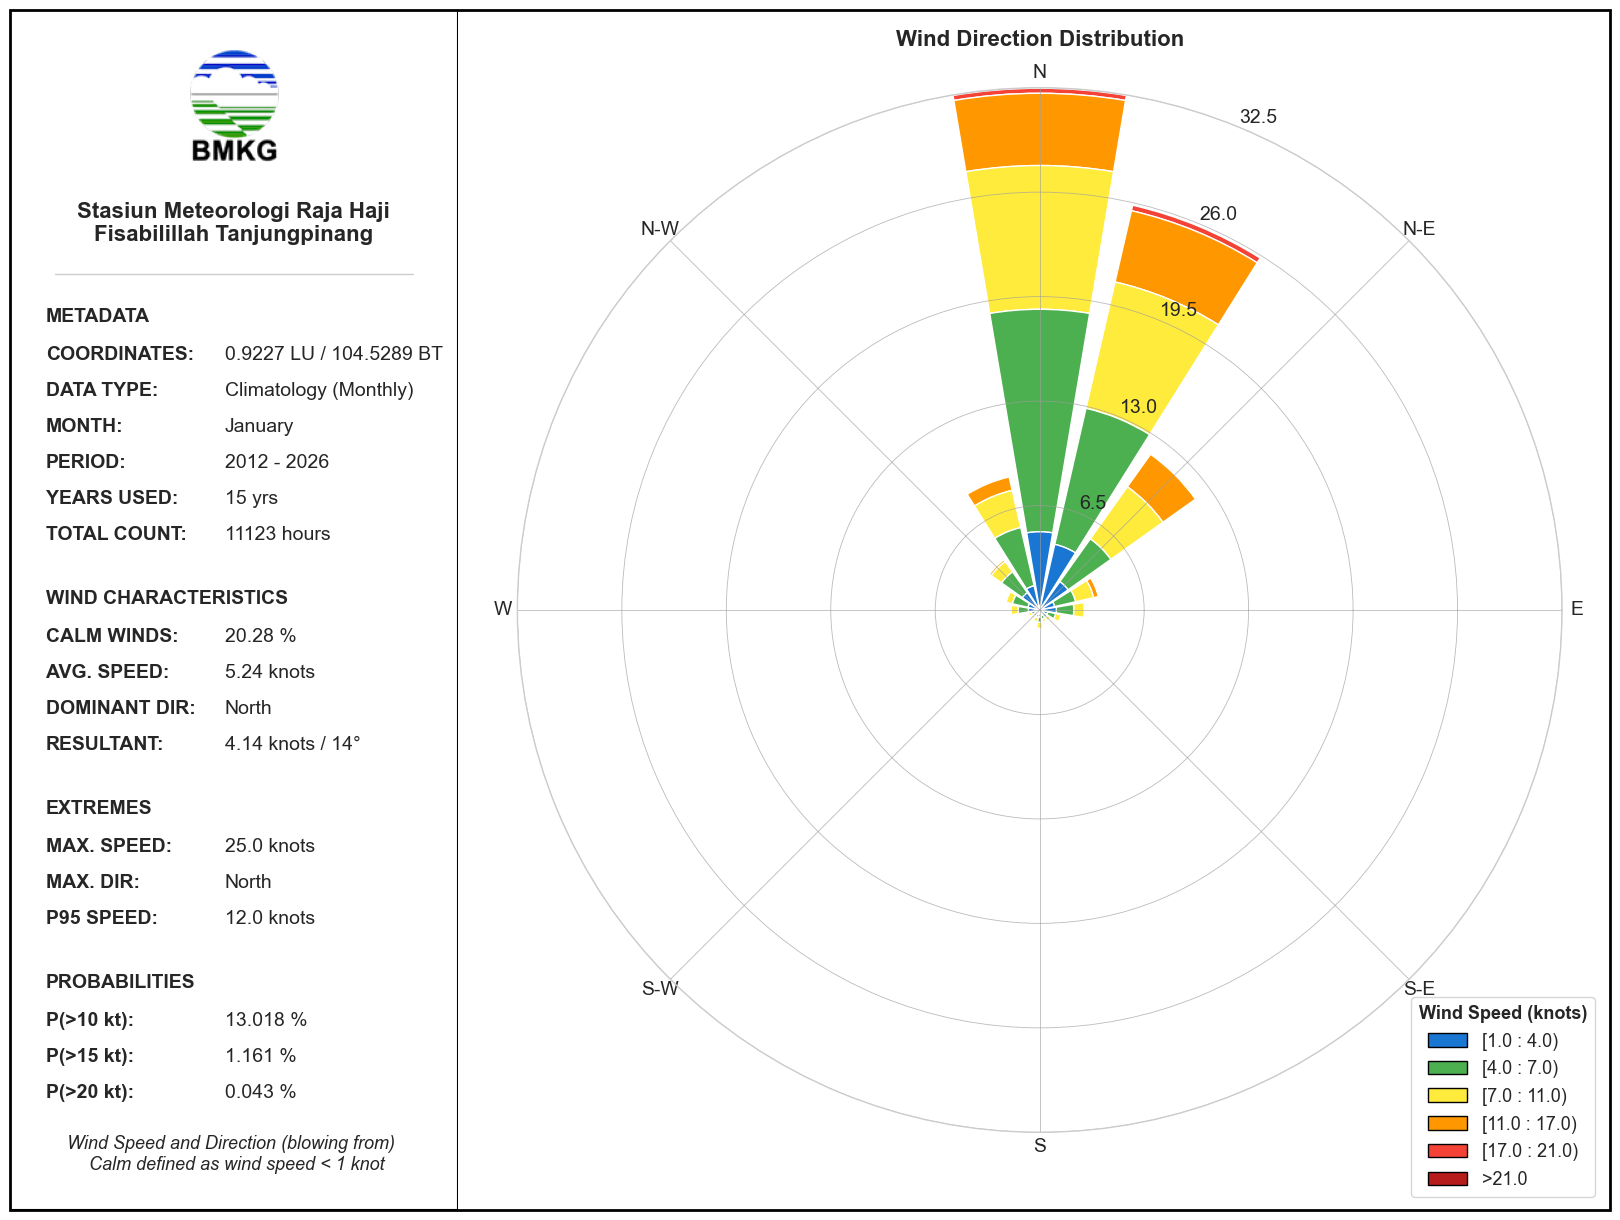

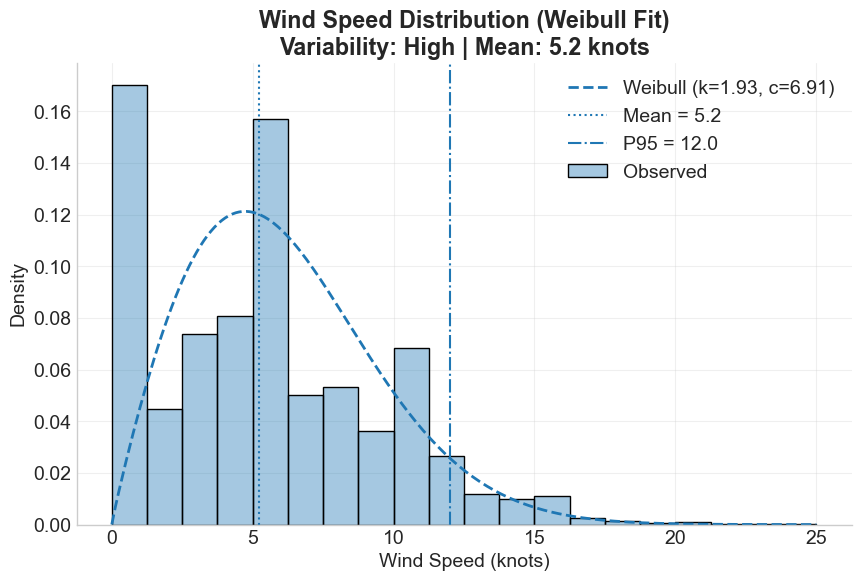

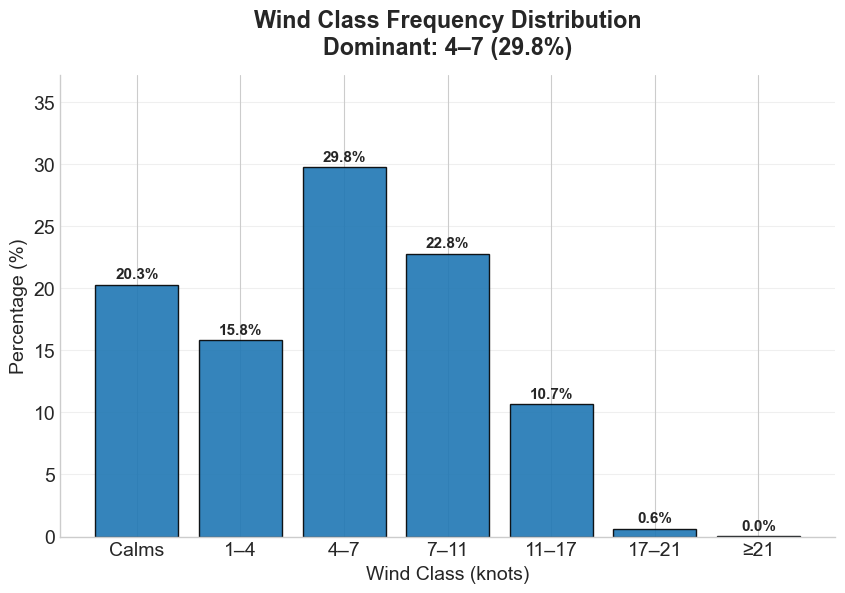

Reports saved for: January (2012 - 2026) -> windrose_climatology_01_2012_2026.png


In [429]:
# ## 5. Execution

try:
    df_full = load_data()
    # Example 1: Monthly
    # generate_report(df_full, mode="monthly", year=2012, month=1)
    # Example 2: Climatology
    generate_report(df_full, mode="climatology_month", month=1, start_year=2012, end_year=2026)
except Exception as e:
    print(f"Error: {e}")